## Initialisation et vérification fichier DVF

In [1]:
import pandas as pd
import numpy as np

# Chargement du dataset
df = pd.read_csv('dvf_clean_final_avantML.csv')

# Inspection des colonnes disponibles
print("Colonnes du dataset :")
print(df.columns.tolist())

# Aperçu des premières lignes
df.head()

C:\Users\carine\AppData\Local\Temp\ipykernel_18352\1331484723.py:5: DtypeWarning: Columns (0: code_commune, 1: code_departement) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dvf_clean_final_avantML.csv')


Colonnes du dataset :
['date_mutation', 'numero_disposition', 'nature_mutation', 'valeur_fonciere', 'code_postal', 'code_commune', 'code_departement', 'id_parcelle', 'nombre_lots', 'code_type_local', 'type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'longitude', 'latitude', 'annee_mutation', 'mois_mutation', 'jour_semaine', 'is_neuf', 'type_voie', 'ratio_surf_piece', 'has_terrain', 'prix_m2']


,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,code_postal,code_commune,code_departement,id_parcelle,nombre_lots,code_type_local,...,longitude,latitude,annee_mutation,mois_mutation,jour_semaine,is_neuf,type_voie,ratio_surf_piece,has_terrain,prix_m2
0,2020-07-16,1,Vente,22000.0,1160.0,1273,1,01273000AD0038,0,1.0,...,5.375781,46.079010,2020,7,3,0,RUE,32.000000,1,229.166667
1,2020-09-19,1,Vente,93300.0,14390.0,14724,14,14724000AI0035,1,2.0,...,-0.156799,49.283990,2020,9,5,0,AV,13.000000,0,3588.461538
2,2020-09-10,1,Vente,223000.0,14310.0,14752,14,14752000AK0149,0,1.0,...,-0.654175,49.075644,2020,9,3,0,SQ,22.600000,1,1973.451327
3,2020-09-17,1,Vente,194000.0,14440.0,14228,14,14228000AD0312,0,1.0,...,-0.371700,49.290278,2020,9,3,0,RUE,23.333333,1,2771.428571
4,2020-09-10,1,Vente,83000.0,14810.0,14409,14,14409000AA0192,1,2.0,...,-0.204951,49.284326,2020,9,3,0,AV,26.000000,0,1596.153846


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Définition des types pour les codes géographiques
dtypes = {
    'code_commune': str,
    'code_departement': str,
    'code_postal': str
}

df = pd.read_csv('dvf_clean_final_avantML.csv', dtype=dtypes, low_memory=False)

# Suppression immédiate de 'prix_m2' pour éviter la fuite de données (Data Leakage)
df = df.drop(columns=['prix_m2'])

## SPLIT
Pour garantir l'intégrité scientifique du rapport, nous avons appliqué un fractionnement strict des données avant toute transformation :

Base d'entraînement : 3 721 392 transactions (80%). Ce volume massif assure la robustesse de l'apprentissage sur l'ensemble du territoire national.

Base de test : 930 348 transactions (20%). Ce jeu de données "aveugle" sert de juge de paix pour le calcul final de nos métriques de performance.

In [3]:
# Définition de la cible et des features
X = df.drop(columns=['valeur_fonciere'])
y = df['valeur_fonciere']

# Split 80/20
# On utilise random_state pour que tes résultats soient reproductibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entraînement : {X_train.shape[0]} lignes")
print(f"Test : {X_test.shape[0]} lignes")

Entraînement : 3721392 lignes
Test : 930348 lignes


## Procédure de sauvegarde en log des 4 fichiers entraienements et test 

In [4]:
import pandas as pd
import numpy as np

# 1. On applique le log sur y (opération sûre car point par point)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 2. Sauvegarde des fichiers
# On utilise index=False pour ne pas créer de colonne fantôme à la recharge
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train_log.to_csv('y_train.csv', index=False)
y_test_log.to_csv('y_test.csv', index=False)

print("Les 4 fichiers sont prêts à être partagés !")

Les 4 fichiers sont prêts à être partagés !


## Chargement fichiers et code

In [8]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# =================================================================
# 1. CONFIGURATION DU CHARGEMENT (SOCLE COMMUN COLLÈGUES)
# =================================================================

dtypes_geos = {
    'code_commune': str, 
    'code_departement': str, 
    'code_postal': str,
    'id_parcelle': str, 
    'code_type_local': str
}

print("Chargement des données...")
X_train = pd.read_csv('X_train.csv', dtype=dtypes_geos)
X_test = pd.read_csv('X_test.csv', dtype=dtypes_geos)
y_train = pd.read_csv('y_train.csv').iloc[:, 0]
y_test = pd.read_csv('y_test.csv').iloc[:, 0]

# =================================================================
# 2. PIPELINE DE TRANSFORMATION (ALIGNÉ RENDU 1 & 2)
# =================================================================

# --- Variables Numériques (Standardisées) ---
# Ajout de l'aspect temporel (mois/année) pour capter la saisonnalité
num_features = [
    'surface_reelle_bati', 
    'nombre_pieces_principales', 
    'surface_terrain', 
    'longitude', 
    'latitude', 
    'ratio_surf_piece', 
    'nombre_lots',
    'mois_mutation', 
    'annee_mutation'
]

# --- Variables Catégorielles (One-Hot Encoding) ---
# On utilise code_departement (gérable en RAM) plutôt que code_commune.
# On ajoute has_terrain (binaire) pour la précision physique.
cat_features = [
    'type_local', 
    'nature_mutation', 
    'code_departement', 
    'has_terrain'
]

# Sécurité : on ne garde que les colonnes réellement présentes dans le fichier
num_features = [f for f in num_features if f in X_train.columns]
cat_features = [f for f in cat_features if f in X_train.columns]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# =================================================================
# 3. FONCTION D'ÉVALUATION UNIVERSELLE (AVEC RMSE & GAP)
# =================================================================

def evaluate_model_performance(model, X_test, y_test_log, X_train=None, y_train_log=None, model_name="Modèle"):
    """
    Calcule et affiche R², MAPE, MAE et RMSE en Euros.
    Compare avec le Train pour mesurer le surapprentissage.
    """
    # --- Évaluation sur le Test ---
    y_pred_log = model.predict(X_test)
    y_true = np.expm1(y_test_log)
    y_pred = np.expm1(y_pred_log)
    
    mape_test = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"\n" + "="*50)
    print(f" RÉSULTATS : {model_name.upper()}")
    print(f"="*50)
    print(f"R² (Variance expliquée)     : {r2:.3f}")
    print(f"MAPE (Erreur relative)      : {mape_test:.2f} %")
    print(f"MAE (Erreur moyenne)        : {mae:.0f} €")
    print(f"RMSE (Sensibilité outliers) : {rmse:.0f} €")
    
    # --- Calcul du Gap (Diagnostic Overfitting) ---
    if X_train is not None and y_train_log is not None:
        y_train_pred_log = model.predict(X_train)
        mape_train = mean_absolute_percentage_error(np.expm1(y_train_log), np.expm1(y_train_pred_log)) * 100
        gap = mape_test - mape_train
        print(f"-"*50)
        print(f"MAPE Train : {mape_train:.2f} %")
        print(f"GAP (Test - Train) : {gap:.2f} pts")
        if gap > 10: print("⚠️ Alerte : Risque élevé de surapprentissage !")
        
    print(f"="*50)
    
    return {"R2": r2, "MAPE": mape_test, "MAE": mae, "RMSE": rmse}

Chargement des données...


# Modèles Linéaires (Baselines)
Régression Linéaire et la Régression Ridge.

### Modèle 1 : Linear Regression (MCO)

In [10]:
from sklearn.linear_model import LinearRegression

# Construction du Pipeline (Utilise le preprocessor défini dans le socle)
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entraînement sur les 3 721 392 lignes
pipe_lr.fit(X_train, y_train)

# Évaluation avec la nouvelle fonction (pense à passer X_train pour avoir le GAP)
results_lr = evaluate_model_performance(
    pipe_lr, 
    X_test, 
    y_test, 
    X_train, 
    y_train, 
    "Linear Regression"
)


 RÉSULTATS : LINEAR REGRESSION
R² (Variance expliquée)     : 0.332
MAPE (Erreur relative)      : 52.24 %
MAE (Erreur moyenne)        : 100943 €
RMSE (Sensibilité outliers) : 202407 €
--------------------------------------------------
MAPE Train : 52.40 %
GAP (Test - Train) : -0.17 pts


## Modèle 2 : Ridge Regression (Régularisation L2)

In [11]:
from sklearn.linear_model import Ridge

# 1. Construction du Pipeline
# Le preprocessor inclut maintenant : département, mois, année, ratio_surf, etc.
pipe_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

# 2. Entraînement 
print("Entraînement du modèle Ridge en cours...")
pipe_ridge.fit(X_train, y_train)

# 3. Évaluation via la fonction universelle
# On passe X_train/y_train pour vérifier si la régularisation aide contre l'overfitting
results_ridge = evaluate_model_performance(
    pipe_ridge, 
    X_test, 
    y_test, 
    X_train, 
    y_train, 
    "Ridge Regression"
)

Entraînement du modèle Ridge en cours...

 RÉSULTATS : RIDGE REGRESSION
R² (Variance expliquée)     : 0.332
MAPE (Erreur relative)      : 52.24 %
MAE (Erreur moyenne)        : 100956 €
RMSE (Sensibilité outliers) : 202444 €
--------------------------------------------------
MAPE Train : 52.41 %
GAP (Test - Train) : -0.17 pts


# 3. Ensemble Learning : Bagging (Random Forest & ExtraTrees)

## . Modèle 3 : Random Forest

In [12]:
from sklearn.ensemble import RandomForestRegressor

# 1. Construction du Pipeline Random Forest
# On utilise le même preprocessor (département, dates, surfaces, etc.)
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=50, 
        max_depth=10, 
        n_jobs=-1, 
        random_state=42
    ))
])

# 2. Entraînement 
print("Entraînement du modèle Random Forest en cours (cela peut prendre quelques minutes)...")
pipe_rf.fit(X_train, y_train)

# 3. Évaluation via la fonction universelle
# Important de garder X_train pour vérifier si la RF surapprend (souvent le cas avec les arbres)
results_rf = evaluate_model_performance(
    pipe_rf, 
    X_test, 
    y_test, 
    X_train, 
    y_train, 
    "Random Forest"
)

Entraînement du modèle Random Forest en cours (cela peut prendre quelques minutes)...

 RÉSULTATS : RANDOM FOREST
R² (Variance expliquée)     : 0.478
MAPE (Erreur relative)      : 51.39 %
MAE (Erreur moyenne)        : 92186 €
RMSE (Sensibilité outliers) : 179008 €
--------------------------------------------------
MAPE Train : 51.28 %
GAP (Test - Train) : 0.11 pts


## Modèle 4 : ExtraTrees (Extremely Randomized Trees)

In [13]:
from sklearn.ensemble import ExtraTreesRegressor

# 1. Construction du Pipeline Extra Trees (Mêmes réglages pour comparaison directe)
pipe_et = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(
        n_estimators=50, 
        max_depth=10, 
        n_jobs=-1, 
        random_state=42
    ))
])

# 2. Entraînement 
print("Entraînement du modèle Extra Trees en cours...")
pipe_et.fit(X_train, y_train)

# 3. Évaluation via la fonction universelle
results_et = evaluate_model_performance(
    pipe_et, 
    X_test, 
    y_test, 
    X_train, 
    y_train, 
    "Extra Trees"
)

Entraînement du modèle Extra Trees en cours...

 RÉSULTATS : EXTRA TREES
R² (Variance expliquée)     : 0.424
MAPE (Erreur relative)      : 54.39 %
MAE (Erreur moyenne)        : 97518 €
RMSE (Sensibilité outliers) : 187977 €
--------------------------------------------------
MAPE Train : 54.41 %
GAP (Test - Train) : -0.02 pts


# 4. Ensemble Modèle Bagging : LightGBM et Xboost

## LightGBM

In [15]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# =================================================================
# 1. MODÈLE : LIGHTGBM (Rapide & Performant sur gros volumes)
# =================================================================
pipe_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        n_jobs=-1,
        random_state=42
    ))
])

print("Entraînement de LightGBM...")
pipe_lgbm.fit(X_train, y_train)
results_lgbm = evaluate_model_performance(pipe_lgbm, X_test, y_test, X_train, y_train, "LightGBM")

Entraînement de LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.136957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1548
[LightGBM] [Info] Number of data points in the train set: 3721392, number of used features: 112
[LightGBM] [Info] Start training from score 12.109829


c:\Users\carine\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 RÉSULTATS : LIGHTGBM
R² (Variance expliquée)     : 0.549
MAPE (Erreur relative)      : 39.31 %
MAE (Erreur moyenne)        : 76018 €
RMSE (Sensibilité outliers) : 166326 €


c:\Users\carine\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


--------------------------------------------------
MAPE Train : 39.36 %
GAP (Test - Train) : -0.05 pts


## MODÈLE : XGBOOST

In [17]:
from xgboost import XGBRegressor

# 1. Construction du Pipeline XGBoost uniquement
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=10,
        tree_method='hist', # Indispensable pour la rapidité sur 3,7M de lignes
        n_jobs=-1,
        random_state=42
    ))
])

# 2. Entraînement
print("Entraînement de XGBoost en cours...")
pipe_xgb.fit(X_train, y_train)

# 3. Évaluation
results_xgb = evaluate_model_performance(
    pipe_xgb, 
    X_test, 
    y_test, 
    X_train, 
    y_train, 
    "XGBoost"
)

Entraînement de XGBoost en cours...

 RÉSULTATS : XGBOOST
R² (Variance expliquée)     : 0.651
MAPE (Erreur relative)      : 35.03 %
MAE (Erreur moyenne)        : 67237 €
RMSE (Sensibilité outliers) : 146331 €
--------------------------------------------------
MAPE Train : 34.50 %
GAP (Test - Train) : 0.52 pts


# Optimisation par GridSearchCV

In [19]:
from sklearn.model_selection import RandomizedSearchCV

# 1. On définit une grille plus légère
param_dist = {
    'regressor__n_estimators': [100, 150],
    'regressor__max_depth': [8, 10],
    'regressor__learning_rate': [0.05, 0.1]
}

# 2. Utilisation de RandomizedSearchCV
# n_iter=4 : il va tester 4 combinaisons au hasard (évite l'explosion mémoire)
# n_jobs=2 : on ne prend que 2 cœurs pour laisser de la RAM disponible
random_search = RandomizedSearchCV(
    pipe_xgb, 
    param_distributions=param_dist, 
    n_iter=4, 
    cv=2, # On réduit à 2 folds pour limiter les copies de données
    scoring='r2', 
    n_jobs=2, 
    verbose=3,
    random_state=42
)

print("Optimisation allégée en cours...")
try:
    random_search.fit(X_train, y_train)
    print(f"Meilleurs paramètres : {random_search.best_params_}")
except Exception as e:
    print(f"Erreur encore présente : {e}")
    print("Conseil : Ton dataset est trop gros pour un GridSearch sur cette machine.")

Optimisation allégée en cours...
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Meilleurs paramètres : {'regressor__n_estimators': 150, 'regressor__max_depth': 10, 'regressor__learning_rate': 0.1}


## MODELE CHAMPION XGBoost 

In [21]:
from xgboost import XGBRegressor

# 1. Configuration du Pipeline avec les paramètres optimisés
pipe_xgb_champion = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=150,      # Optimisé via RandomizedSearchCV
        learning_rate=0.1,     # Optimisé via RandomizedSearchCV
        max_depth=10,          # Optimisé via RandomizedSearchCV
        tree_method='hist',    # Pour la performance sur gros volume
        n_jobs=-1,
        random_state=42
    ))
])

# 2. Entraînement sur l'ensemble du set d'entraînement
print("Entraînement du modèle Champion XGBoost en cours...")
pipe_xgb_champion.fit(X_train, y_train)

# 3. Évaluation finale
results_champion = evaluate_model_performance(
    pipe_xgb_champion, 
    X_test, 
    y_test, 
    X_train, 
    y_train, 
    "XGBOOST CHAMPION"
)

Entraînement du modèle Champion XGBoost en cours...

 RÉSULTATS : XGBOOST CHAMPION
R² (Variance expliquée)     : 0.672
MAPE (Erreur relative)      : 34.01 %
MAE (Erreur moyenne)        : 65163 €
RMSE (Sensibilité outliers) : 141761 €
--------------------------------------------------
MAPE Train : 33.29 %
GAP (Test - Train) : 0.72 pts


## Importance des variables pour le modèle Champion Xboost 

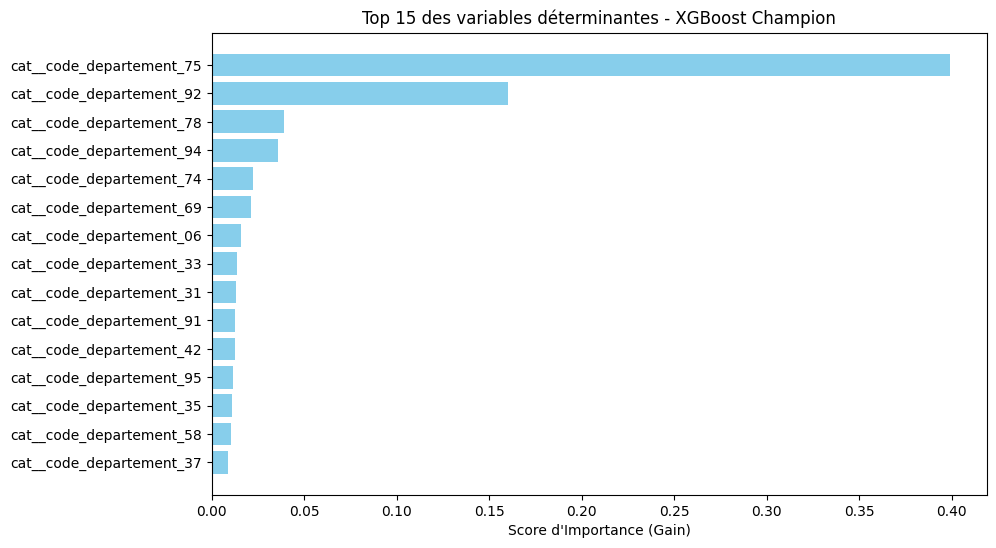

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Récupération des importances
feature_names = pipe_xgb_champion.named_steps['preprocessor'].get_feature_names_out()
importances = pipe_xgb_champion.named_steps['regressor'].feature_importances_

# 2. Création d'un DataFrame pour faciliter l'affichage
df_importance = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_importance = df_importance.sort_values(by='importance', ascending=False).head(15)

# 3. Affichage
plt.figure(figsize=(10, 6))
plt.barh(df_importance['feature'], df_importance['importance'], color='skyblue')
plt.xlabel('Score d\'Importance (Gain)')
plt.title('Top 15 des variables déterminantes - XGBoost Champion')
plt.gca().invert_yaxis()
plt.show()

## SHAP sur Champion XGBoost

In [24]:
!pip install shap

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 7.5 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ------ --------------------------------- 6.0/39.2 MB 30.8 MB/s eta 0:00:02
   ------------- -------------------------- 13.1/39.2 MB 32.9 MB/s eta 0:00:01
   -------------------- ------------------- 20.2/39.2 MB 33.4 MB/s eta 0:00:01
   --------------------------- ------------ 26.7/39.2 MB 32.9 MB/s eta 0:00:01
   ---------------------------------- ----- 34.1/39.2 MB 33.2 MB/s eta 0:00:01
   ---------------------------------------  39.1/39.2 MB 33.3 MB/s eta 0:00:01
   ---------------------------------------- 39.2/39.2 MB 27.2 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 24.1 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\carine\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


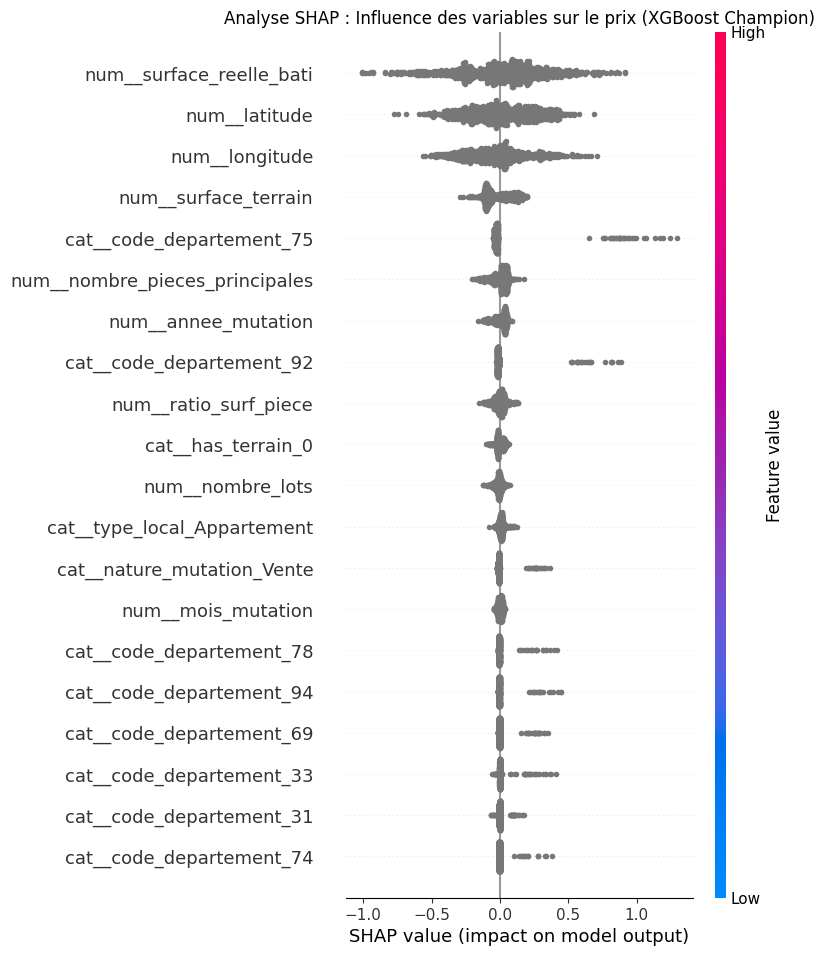

In [25]:
import shap
import matplotlib.pyplot as plt

# 1. Préparation des données transformées
# On prend un échantillon du test set pour éviter de saturer la RAM
X_sample = X_test.sample(1000, random_state=42)
X_sample_preprocessed = pipe_xgb_champion.named_steps['preprocessor'].transform(X_sample)
feature_names = pipe_xgb_champion.named_steps['preprocessor'].get_feature_names_out()

# 2. Création de l'explainer SHAP dédié aux arbres (XGBoost)
explainer = shap.TreeExplainer(pipe_xgb_champion.named_steps['regressor'])
shap_values = explainer.shap_values(X_sample_preprocessed)

# 3. Affichage du Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample_preprocessed, feature_names=feature_names, show=False)
plt.title("Analyse SHAP : Influence des variables sur le prix (XGBoost Champion)")
plt.show()

## Sauvergarde du modèle

In [26]:
import joblib

# 1. Sauvegarde du Pipeline COMPLET (Prétraitement + XGBoost) - Le plus important pour votre collègue
joblib.dump(pipe_xgb_champion, 'modele_immobilier_champion.joblib')

# 2. Sauvegarde du modèle XGBoost seul en format JSON (comme demandé)
model_xgb = pipe_xgb_champion.named_steps['regressor']
model_xgb.save_model('modele_immobilier_champion.json')

print("Modèles sauvegardés avec succès !")

Modèles sauvegardés avec succès !
